# Practical 3: Convolutional Neural Network (CNN)
**Problem:** Fashion Clothing Classification  
**Dataset:** fashion-mnist_train.csv & fashion-mnist_test.csv (local)  
**Type:** Multi-class Classification → 10 categories of clothing

---
### What changed from P1/P2?
| Step | P1 (Regression) | P2 (Binary) | P3 (CNN) |
|------|-----------------|-------------|----------|
| Input Shape | (13,) flat | (5000,) TF-IDF | (28,28,1) image |
| Preprocessing | StandardScaler | TF-IDF | Reshape + /255.0 |
| Model Layers | Dense only | Dense only | Conv2D + MaxPool + Dense |
| Last Layer | Dense(1) | Dense(1, sigmoid) | Dense(10, softmax) |
| Loss | mse | binary_crossentropy | sparse_categorical_crossentropy |

## STEP 1: Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,       # ← NEW: Convolutional layer (extracts image features)
    MaxPooling2D, # ← NEW: Downsamples feature maps
    Dropout,      # ← NEW: Regularization (prevents overfitting)
    Flatten,      # ← NEW: Converts 2D→1D for Dense layers
    Dense
)

## STEP 2: Load Dataset
**Fashion MNIST CSV format:**  
- Column 0 = Label (0-9, the clothing category)  
- Columns 1-784 = Pixel values (28×28 = 784 pixels, values 0-255)

In [2]:
# ── SWAP THIS BLOCK to change dataset ──────────────────────────────────────
train_df = pd.read_csv('fashion_train.csv')
test_df  = pd.read_csv('fashion_test.csv')

# Class names for the 10 categories
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]
# ───────────────────────────────────────────────────────────────────────────

print("Train shape:", train_df.shape)        # (60000, 785)
print("Test shape:",  test_df.shape)          # (10000, 785)
print("Label column: 'label', first value:", train_df.iloc[0, 0])

Train shape: (1000, 785)
Test shape: (1000, 785)
Label column: 'label', first value: 0


## STEP 3: Preprocess Data
**Key steps:**
1. Separate labels from pixels
2. Reshape flat (784,) → image (28, 28, 1) — the 1 = grayscale channel
3. Normalize pixel values: divide by 255 → range [0, 1]

X_train shape: (1000, 28, 28, 1)
y_train shape: (1000,)


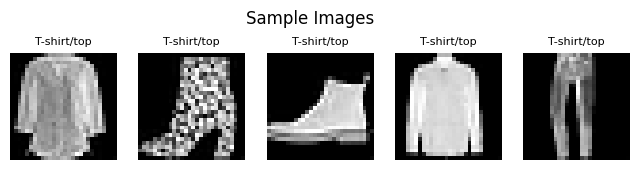

In [3]:
# ── SWAP THIS BLOCK for different image datasets ────────────────────────────
X_train = train_df.iloc[:, 1:].to_numpy()                  # All columns except label
y_train = train_df.iloc[:, 0].to_numpy()                   # First column = label

X_test  = test_df.iloc[:, 1:].to_numpy()
y_test  = test_df.iloc[:, 0].to_numpy()

# Reshape: (samples, 784) → (samples, 28, 28, 1)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0           # ← Normalize to [0, 1]
X_test  = X_test.reshape(-1, 28, 28, 1)  / 255.0
# ───────────────────────────────────────────────────────────────────────────

print("X_train shape:", X_train.shape)      # (60000, 28, 28, 1)
print("y_train shape:", y_train.shape)

# Visualize a sample
plt.figure(figsize=(8, 2))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i].reshape(28, 28), cmap='gray')
    plt.title(class_names[y_train[i]], fontsize=8)
    plt.axis('off')
plt.suptitle('Sample Images'); plt.show()

## STEP 4: Build the CNN Model
**CNN Architecture Flow:**  
`Image (28×28×1)` → `Conv2D` → `MaxPool` → `Dropout` → `Flatten` → `Dense` → `Softmax (10 classes)`

- **Conv2D**: Slides a filter over the image, detects edges/shapes  
- **MaxPooling2D**: Shrinks the feature map (keeps most important features)  
- **Dropout**: Randomly turns off neurons during training (prevents overfitting)  
- **Flatten**: Converts 2D feature maps → 1D vector  
- **softmax**: Converts scores into probabilities for 10 classes

In [4]:
# ── SWAP THIS BLOCK to change model architecture ────────────────────────────
model = Sequential([
    Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    # ↑ 64 filters, each 3×3 pixels, relu removes negatives
    MaxPooling2D((2, 2)),
    # ↑ Takes max in 2×2 window → halves dimensions (26×26 → 13×13)
    Dropout(0.3),
    # ↑ 30% of neurons randomly set to 0 during training
    Flatten(),
    # ↑ 13×13×64 = 10816 values → flat vector
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')                      # ← 10 classes → softmax
    # P2 (Binary):   Dense(1, activation='sigmoid')
    # P1 (Regression): Dense(1)
])
# ───────────────────────────────────────────────────────────────────────────

model.summary()

C:\Users\Lenovo\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 64)          │             640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 13, 13, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 10816)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │         346,144 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             330 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 347,114 (1.32 MB)

 Trainable params: 347,114 (1.32 MB)

 Non-trainable params: 0 (0.00 B)

## STEP 5: Compile the Model

In [5]:
# ── SWAP loss when changing task ─────────────────────────────────────────────
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # ← Multi-class (integer labels)
    # Use 'categorical_crossentropy' if labels are one-hot encoded
    metrics=['accuracy']
)
# ───────────────────────────────────────────────────────────────────────────

## STEP 6: Train the Model

In [6]:
# ── COMMON BLOCK ────────────────────────────────────────────────────────────
history = model.fit(
    X_train, y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
# ───────────────────────────────────────────────────────────────────────────

Epoch 1/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.9575 - loss: 0.3086 - val_accuracy: 1.0000 - val_loss: 3.2342e-05
Epoch 2/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9975 - loss: 0.0647 - val_accuracy: 1.0000 - val_loss: 3.6564e-05
Epoch 3/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9975 - loss: 0.0468 - val_accuracy: 1.0000 - val_loss: 0.0013
Epoch 4/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9975 - loss: 0.0225 - val_accuracy: 1.0000 - val_loss: 0.0033
Epoch 5/5
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9975 - loss: 0.0164 - val_accuracy: 1.0000 - val_loss: 0.0028


## STEP 7: Evaluate the Model

In [7]:
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss    : {loss:.4f}")
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Loss    : 0.0024
Test Accuracy: 100.00%


## STEP 8: Visualize Predictions

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


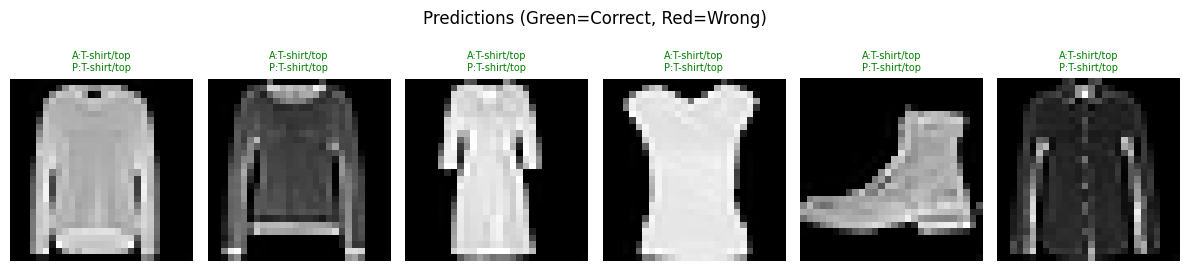

In [8]:
predictions = model.predict(X_test).argmax(axis=1)      # Take class with highest probability

plt.figure(figsize=(12, 3))
for i in range(6):
    plt.subplot(1, 6, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    actual    = class_names[y_test[i]]
    predicted = class_names[predictions[i]]
    color = 'green' if actual == predicted else 'red'
    plt.title(f"A:{actual}\nP:{predicted}", fontsize=7, color=color)
    plt.axis('off')
plt.suptitle('Predictions (Green=Correct, Red=Wrong)')
plt.tight_layout()
plt.show()

## STEP 9: Plot Training History

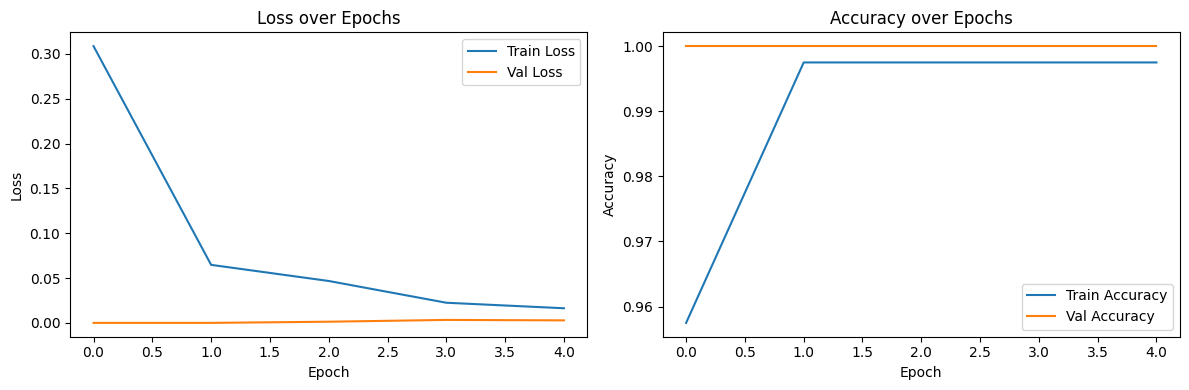

In [9]:
# ── COMMON BLOCK ────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs'); plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout()
plt.show()
# ───────────────────────────────────────────────────────────────────────────